In [47]:
import pandas as pd
import numpy as np

# 读取数据（从 ts_benchmark/baselines 相对位置）
df = pd.read_csv('../../dataset/forecasting/ETTh1.csv')

# 假设数据格式是 (n*x, 3)，第三列是 cols（列名）
# 获取唯一的列名
unique_cols = df.iloc[:, 2].unique()
num_cols = len(unique_cols)

# 获取时间步长
num_samples = len(df) // num_cols

new_dfs = []  # 用于存储新的DataFrame
# 用列名分组
for idx, df_g in enumerate(df.groupby(df.iloc[:, 2])) :
    # print(f"Processing group {idx+1}/{num_cols}: {df_g[0]} with shape {df_g[1].shape}")
    if df_g[1].shape[0] != num_samples:
        print(f"Warning: Group {df_g[0]} has {df_g[1].shape[0]} samples, expected {num_samples}.")

    if idx == 0:
        new_dfs = df_g[1].iloc[:, :-1]# 不要最后一列
        new_dfs.columns = ['time', df_g[0]]  # 重命名列
    else:
        df_t = df_g[1].iloc[:, 1]  # 只保留数值列
        df_t.name = df_g[0]  # 设置列名为当前组的列名
        df_t.index = new_dfs.index  # 确保索引对齐
        new_dfs = pd.concat([new_dfs, df_t], axis=1) # 只保留数值列

print(f"Final new_dfs shape: {new_dfs.shape}")
print(new_dfs.head())




Final new_dfs shape: (17420, 8)
                  time   HUFL   HULL   LUFL   LULL   MUFL   MULL         OT
0  2016-07-01 00:00:00  5.827  2.009  4.203  1.340  1.599  0.462  30.531000
1  2016-07-01 01:00:00  5.693  2.076  4.142  1.371  1.492  0.426  27.787001
2  2016-07-01 02:00:00  5.157  1.741  3.777  1.218  1.279  0.355  27.787001
3  2016-07-01 03:00:00  5.090  1.942  3.807  1.279  1.279  0.391  25.044001
4  2016-07-01 04:00:00  5.358  1.942  3.868  1.279  1.492  0.462  21.948000


In [ ]:

# 增加t_idx, t_dif, mask列
new_dfs['t_idx'] = np.arange(len(new_dfs))
new_dfs['t_dif'] = 1
new_dfs['mask'] = 1  # 初始化mask列为1

print(f"Final new_dfs shape: {new_dfs.shape}")
print(new_dfs.head())

第0列 - 大于阈值的数据点比例: 1.5212 %
第0列 - 当前缺失值数量: 0
------------------------------------------------------------
第1列 - 大于阈值的数据点比例: 6.6590 %
第1列 - 当前缺失值数量: 91
------------------------------------------------------------
第2列 - 大于阈值的数据点比例: 6.1768 %
第2列 - 当前缺失值数量: 308
------------------------------------------------------------
第3列 - 大于阈值的数据点比例: 2.2732 %
第3列 - 当前缺失值数量: 8
------------------------------------------------------------
第4列 - 大于阈值的数据点比例: 0.4650 %
第4列 - 当前缺失值数量: 0
------------------------------------------------------------
第5列 - 大于阈值的数据点比例: 5.1378 %
第5列 - 当前缺失值数量: 71
------------------------------------------------------------
第6列 - 大于阈值的数据点比例: 5.7405 %
第6列 - 当前缺失值数量: 484
------------------------------------------------------------
步骤1 - MNAR_X后缺失率: 0.0000 %


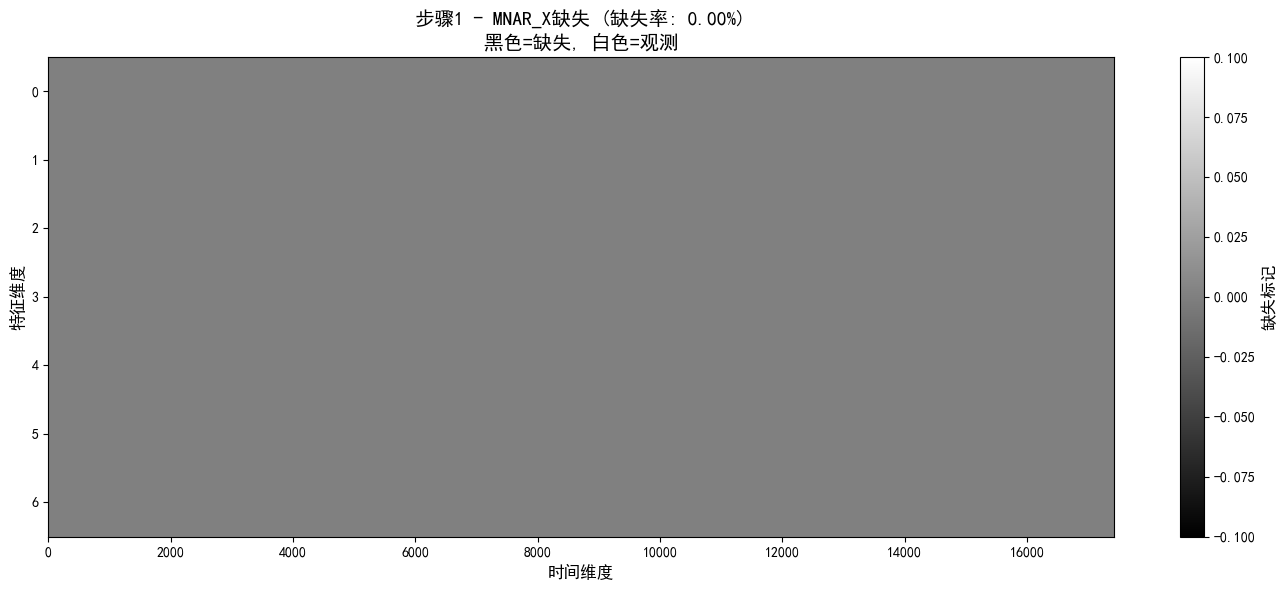

步骤2 - MNAR_T后缺失率: 0.0000 %


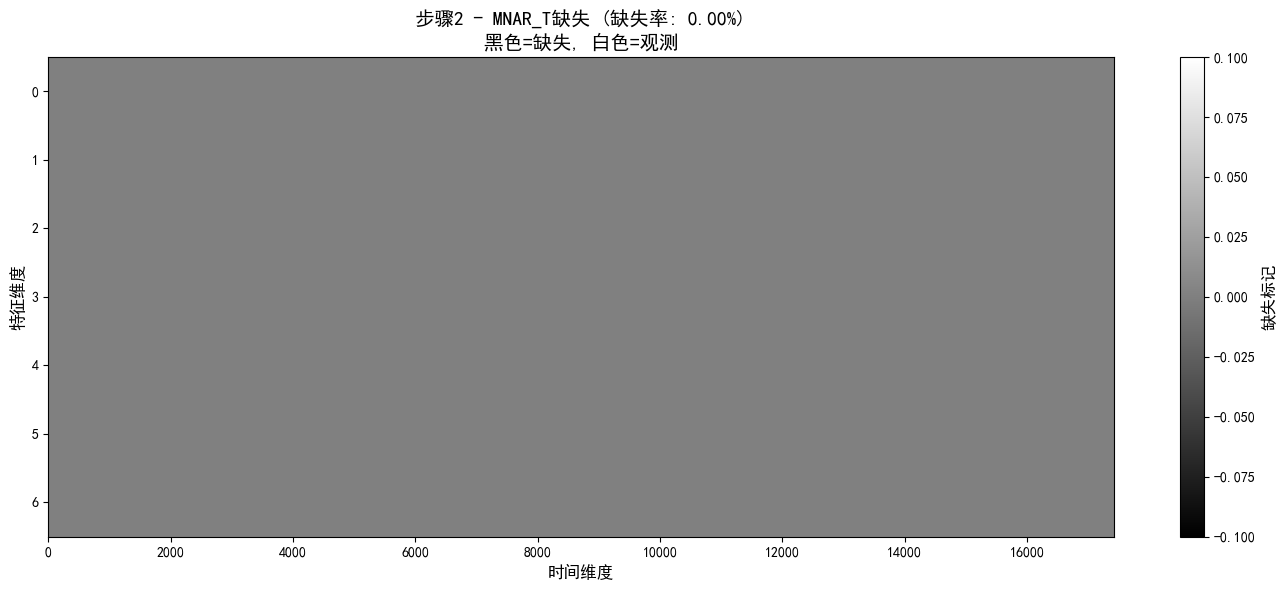

步骤3 - MNAR_Nonuniform后缺失率: 0.8406 %


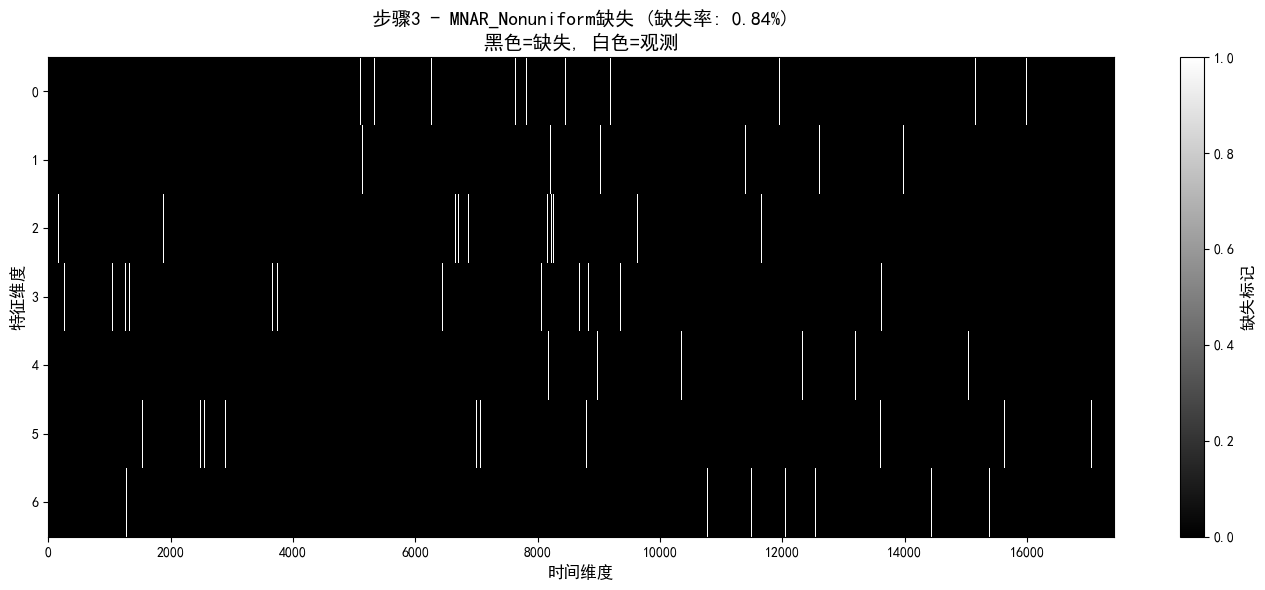

步骤4 - MCAR后缺失率: 1.7837 %


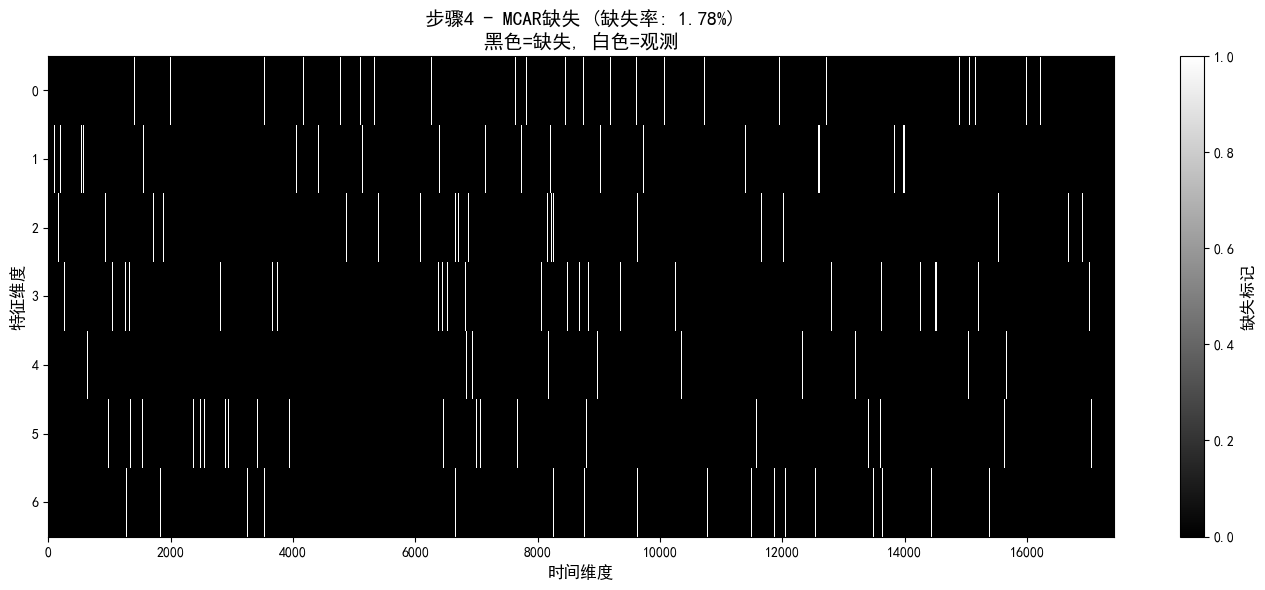

2026-04-22 22:13:54 [WARNING]: hit_rate=17.42 > 1


步骤5 - Seq_Missing后缺失率: 2.5677 %


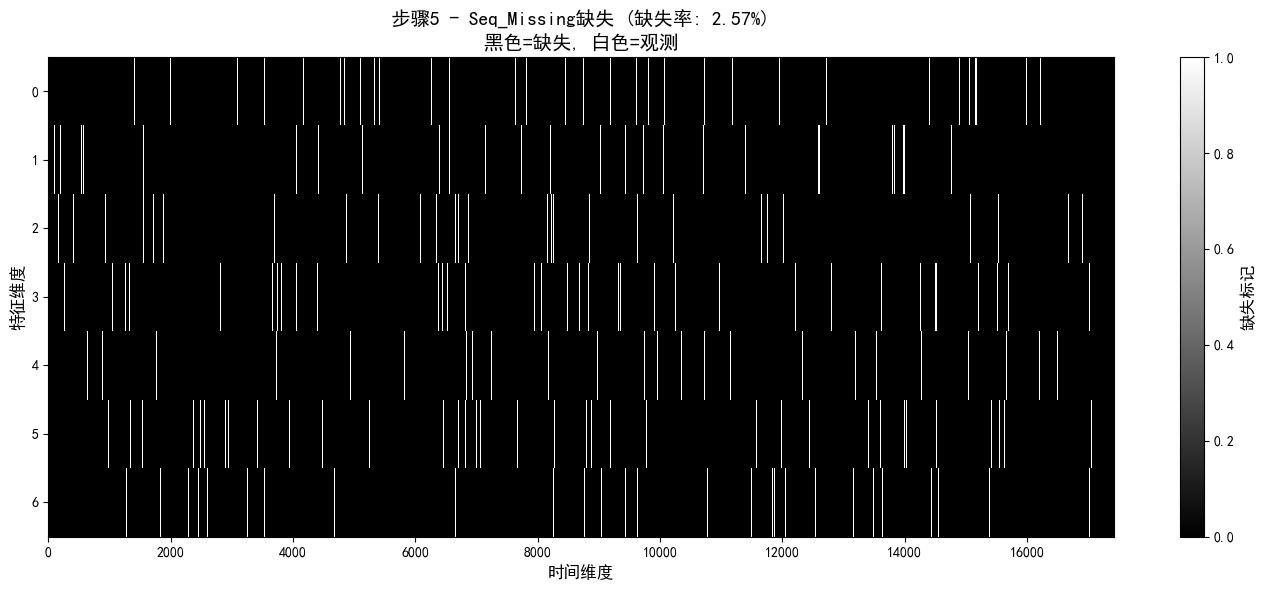

2026-04-22 22:13:54 [WARNING]: hit_rate=8.129333333333333 > 1


步骤6 - Block_Missing后缺失率: 3.0622 %


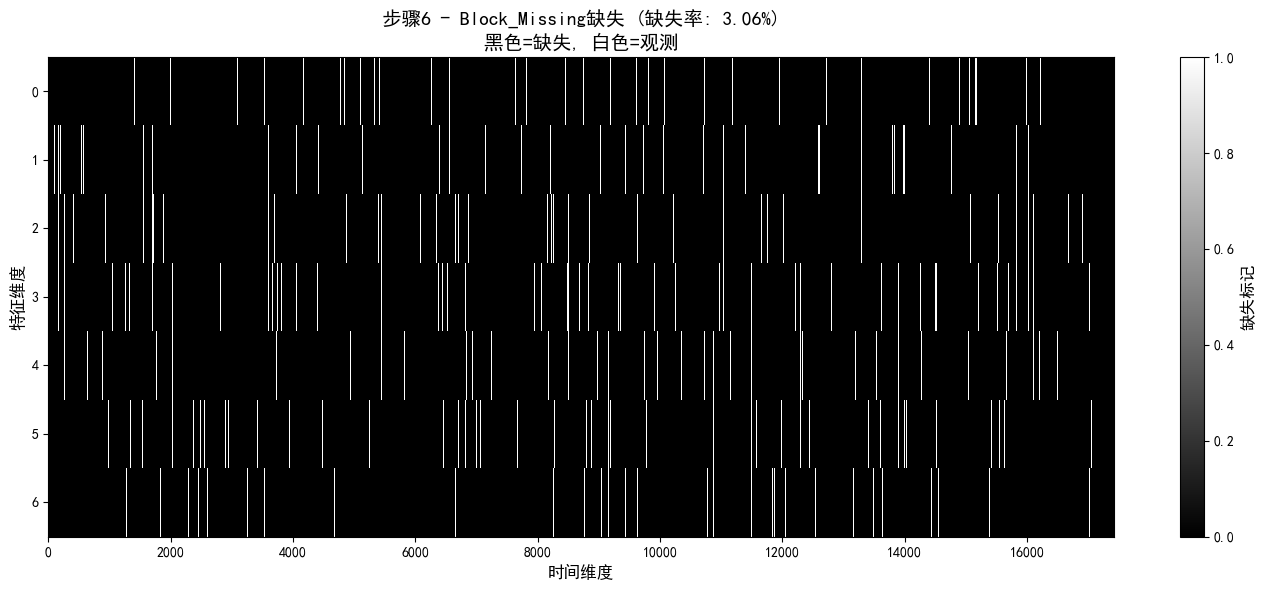


最终缺失率: 3.0622 %


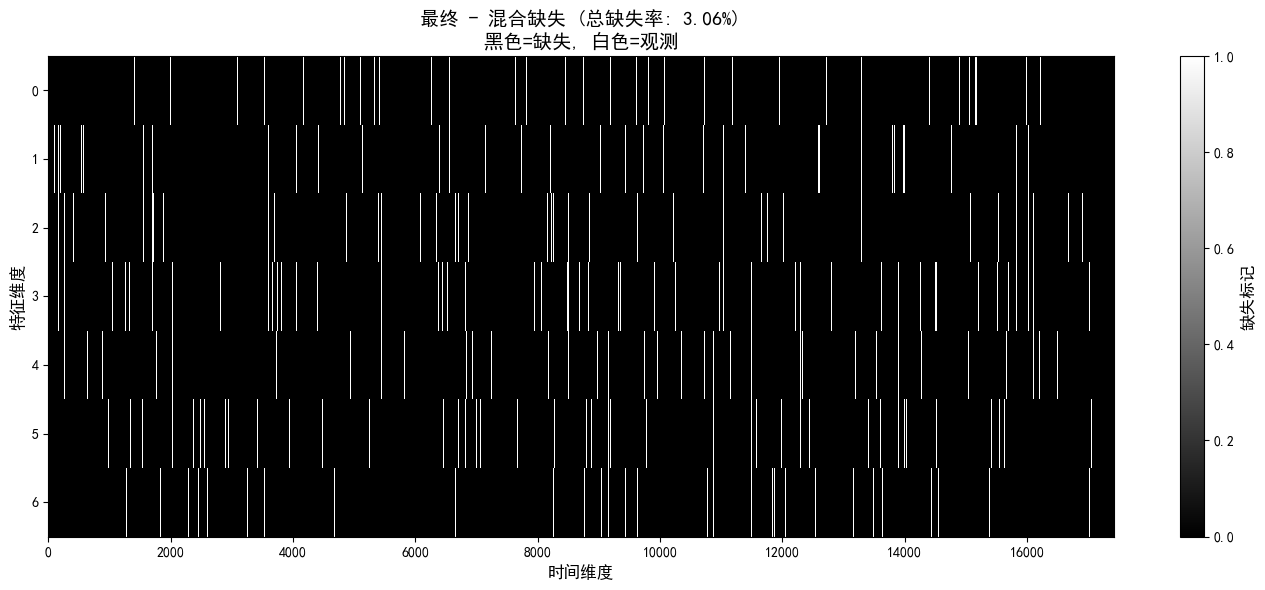

In [60]:
import matplotlib.pyplot as plt
import numpy as np
from pygrinder import (
    mnar_x,
    mnar_t,
    mnar_nonuniform,
    mcar,
    seq_missing,
    calc_missing_rate,
    block_missing,
)

data_1_col = new_dfs.iloc[:, 0]
data_without_time = new_dfs.iloc[:, 1:]
data = data_without_time.values.astype(np.float32)

X_mixed = data.reshape(1, data.shape[0], data.shape[1])

missing_20 = {
    "mnar_x_offset": 1.5,
    "mnar_t_cycle": 168,
    "mnar_t_pos": 84,
    "mnar_t_scale": 0.075,
    "mnar_nonuniform_p": 0.03,
    "mnar_nonuniform_increase_factor": 0.6,
    "mcar_p": 0.04,
    "seq_missing_p": 0.03,
    "seq_missing_seq_len": 8,
    "block_missing_factor": 0.005,
    "block_missing_block_width": 3,
    "block_missing_block_len": 5,
}

missing_5 = {
    "mnar_x_offset": 2.5,
    "mnar_t_cycle": 168,
    "mnar_t_pos": 84,
    "mnar_t_scale": 0.015,
    "mnar_nonuniform_p": 0.008,
    "mnar_nonuniform_increase_factor": 0.5,
    "mcar_p": 0.01,
    "seq_missing_p": 0.008,
    "seq_missing_seq_len": 8,
    "block_missing_factor": 0.001,
    "block_missing_block_width": 3,
    "block_missing_block_len": 5,
}
missing_target = missing_5
def plot_missing_pattern(X, title, step_num):
    """绘制缺失模式"""
    X_2d = X.reshape(X.shape[1], X.shape[2])
    missing_mask = np.isnan(X_2d).astype(int)
    
    # 转置，使特征在x轴，时间在y轴
    missing_mask = missing_mask.T
    
    fig, ax = plt.subplots(figsize=(14, 6))
    im = ax.imshow(missing_mask, cmap='gray', aspect='auto', interpolation='nearest')
    
    ax.set_xlabel('时间维度', fontsize=12)
    ax.set_ylabel('特征维度', fontsize=12)
    ax.set_title(f'{title}\n黑色=缺失, 白色=观测', fontsize=14)
    
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('缺失标记', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(f'step_{step_num}_missing_pattern.png', dpi=100, bbox_inches='tight')
    plt.show()

# 1. MNAR_X缺失 - 值大于该时间序列均值加上 offset*标准差的数值将被标记为缺失
# 按列调用 mnar_x
# for i in range(X_mixed.shape[2]):
#     X_mixed[:, :, i:i+1] = mnar_x(X_mixed[:, :, i:i+1], offset=missing_target["mnar_x_offset"])
#     print(f"步骤1 - MNAR_X后第{i}列缺失率: {100 * calc_missing_rate(X_mixed[:, :, i:i+1]):.4f} %")

# 查看所有列的统计信息
for i in range(X_mixed.shape[2]):
    col_i = X_mixed[0, :, i]
    col_i_clean = col_i[~np.isnan(col_i)]  # 去掉NaN
    
    mean_i = np.mean(col_i_clean)
    std_i = np.std(col_i_clean)
    threshold_i = mean_i + 1.5 * std_i
    col_i_clean = mnar_x(col_i_clean.reshape(1, -1, 1), offset=missing_target["mnar_x_offset"]).reshape(-1)  # 应用MNAR_X
    # print(f"第{i}列 - 均值: {mean_i:.4f}")
    # print(f"第{i}列 - 标准差: {std_i:.4f}")
    # print(f"第{i}列 - 缺失阈值 (均值 + 1.5*std): {threshold_i:.4f}")
    # print(f"第{i}列 - 最大值: {np.max(col_i_clean):.4f}")
    # print(f"第{i}列 - 最小值: {np.min(col_i_clean):.4f}")
    # print(f"第{i}列 - 大于阈值的数据点数: {np.sum(col_i_clean > threshold_i)}")
    print(f"第{i}列 - 大于阈值的数据点比例: {100 * np.sum(col_i_clean > threshold_i) / len(col_i_clean):.4f} %")
    print(f"第{i}列 - 当前缺失值数量: {np.sum(np.isnan(col_i_clean))}")
    print("-" * 60)


# X_mixed = mnar_x(X_mixed, offset=missing_target["mnar_x_offset"])
current_rate = calc_missing_rate(X_mixed)
print(f"步骤1 - MNAR_X后缺失率: {100 * current_rate:.4f} %")
plot_missing_pattern(X_mixed, f"步骤1 - MNAR_X缺失 (缺失率: {100*current_rate:.2f}%)", 1)

# 2. MNAR_T缺失 - 周期性缺失，缺失性由强度函数 f(t) = exp(3*torch.sin(cycle*t + pos)) 生成
X_mixed = mnar_t(X_mixed, cycle=missing_target["mnar_t_cycle"], pos=missing_target["mnar_t_pos"], scale=missing_target["mnar_t_scale"])
current_rate = calc_missing_rate(X_mixed)
print(f"步骤2 - MNAR_T后缺失率: {100 * current_rate:.4f} %")
plot_missing_pattern(X_mixed, f"步骤2 - MNAR_T缺失 (缺失率: {100*current_rate:.2f}%)", 2)

# 3. MNAR_Nonuniform缺失
# 缺失值是根据特征的观测计数引入的，具有可调整的概率，
#     可以为观测不足的特征增加缺失概率。
# p :
#     值可能被标记为缺失的概率。必须在 0 到 1 之间。
#     注意这是目标概率 - 每个特征的实际概率
#     将根据其观测计数进行调整。
# increase_factor :
#         根据观测计数调整替换概率的因子。较高的值
#         将增加从观测不足的特征中删除值的概率。

# 返回-------
# Tuple[Union[np.ndarray, torch.Tensor], Union[np.ndarray, torch.Tensor]] :
#     包含以下内容的元组：
#     - corrupted_X: 包含人工缺失值的原始 X
#     - replacement_probabilities: 用于删除值的概率
X_mixed_result = mnar_nonuniform(X_mixed, p=missing_target["mnar_nonuniform_p"], 
                                 increase_factor=missing_target["mnar_nonuniform_increase_factor"])
X_mixed = X_mixed_result[0]
current_rate = calc_missing_rate(X_mixed)
print(f"步骤3 - MNAR_Nonuniform后缺失率: {100 * current_rate:.4f} %")
plot_missing_pattern(X_mixed, f"步骤3 - MNAR_Nonuniform缺失 (缺失率: {100*current_rate:.2f}%)", 3)

# 4. MCAR缺失 - 完全随机缺失,每个值以p概率独立缺失
X_mixed = mcar(X_mixed, p=missing_target["mcar_p"])
current_rate = calc_missing_rate(X_mixed)
print(f"步骤4 - MCAR后缺失率: {100 * current_rate:.4f} %")
plot_missing_pattern(X_mixed, f"步骤4 - MCAR缺失 (缺失率: {100*current_rate:.2f}%)", 4)

# 5. Seq_Missing缺失 - 序列缺失（每个时间步以p概率开始一个长度为seq_len的缺失序列）
X_mixed = seq_missing(X_mixed, p=missing_target["seq_missing_p"], seq_len=missing_target["seq_missing_seq_len"])
current_rate = calc_missing_rate(X_mixed)
print(f"步骤5 - Seq_Missing后缺失率: {100 * current_rate:.4f} %")
plot_missing_pattern(X_mixed, f"步骤5 - Seq_Missing缺失 (缺失率: {100*current_rate:.2f}%)", 5)

# 6. Block_Missing缺失 - 块缺失（每个时间步以factor概率开始一个宽度为block_width、长度为block_len的缺失块）
X_mixed = block_missing(X_mixed, factor=missing_target["block_missing_factor"], 
                        block_width=missing_target["block_missing_block_width"], block_len=missing_target["block_missing_block_len"])
current_rate = calc_missing_rate(X_mixed)
print(f"步骤6 - Block_Missing后缺失率: {100 * current_rate:.4f} %")
plot_missing_pattern(X_mixed, f"步骤6 - Block_Missing缺失 (缺失率: {100*current_rate:.2f}%)", 6)

# 转换回2D
X_mixed = X_mixed.reshape(data_without_time.shape)

# 最终缺失率
final_rate = calc_missing_rate(X_mixed)
print(f"\n最终缺失率: {100 * final_rate:.4f} %")
plot_missing_pattern(X_mixed.reshape(1, X_mixed.shape[0], X_mixed.shape[1]), 
                     f"最终 - 混合缺失 (总缺失率: {100*final_rate:.2f}%)", 'final')